In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from velox_tools.processing import pushbroom

from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=32,
    threads_per_worker=1,
    memory_limit="16GB",
    # change worker directory to /projekt_agmwend/home_rad/dask-worker-space
    local_directory="/projekt_agmwend/home_rad/Joshua/dask-worker-space",
)

client = Client(cluster)

/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46385 instead
  warnings.warn(
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (30.59s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (30.68s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/contextlib.py:144: U

KeyboardInterrupt: 

Process Dask Worker process (from Nanny):
2025-03-13 01:30:29,705 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-03-13 01:30:29,705 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-03-13 01:30:29,706 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-03-13 01:30:29,706 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
Process Dask Worker process (from Nanny):
  File "/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/asyncio/base_events.py", line 684, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^

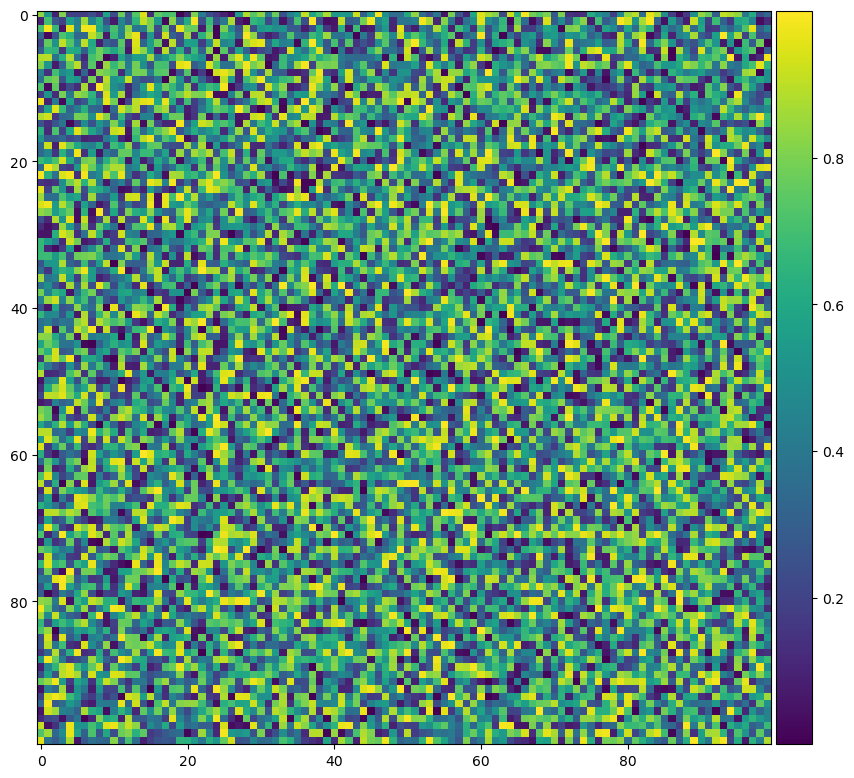

In [8]:
import matplotlib.pyplot as plt
import numpy as np
### add divider and colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

im = np.random.rand(100, 100)
im = ax.imshow(im)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(im, cax=cax)

In [ ]:
ds_raw_bt = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_VELOX_sea_ice/2022-03-20_v_0.1.zarr', engine='zarr', chunks={'time' : 200, 'x' : 200, 'y' : 200, 'band' : 1})
ds_raw_bt = ds_raw_bt.assign_coords({'band' : [1, 2, 3, 5, 6], 'x' : ds_raw_bt.x, 'y' : ds_raw_bt.y})

ds_correction = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/Mueller_et_al_2024/data/correction_fields_v2.nc')

ds_corr = ds_raw_bt.BT_2D - ds_correction.sel(time=ds_raw_bt.time.dt.strftime('%Y-%m-%d').values[0])

/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 200. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 200. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanage

In [ ]:
ds_raw_bt = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_VELOX_sea_ice/2022-04-01_v_0.1.zarr', engine='zarr', chunks='auto')
ds_raw_bt = ds_raw_bt.assign_coords({'band' : [1, 2, 3, 5, 6], 'x' : ds_raw_bt.x, 'y' : ds_raw_bt.y})


/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 202. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 202. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanage

In [ ]:
across_track_correction = ds_corr.isel(y=slice(235, 265)).mean(['y', 'time']) - ds_corr.mean()
across_track_correction = across_track_correction.compute()

In [ ]:
ds_cc = pushbroom(ds_raw_bt.sel(time=slice('2022-04-01T10:00:00', '2022-04-01T10:30:00')))

Executed pushbroom in 49.1920 seconds


In [ ]:
ds_cc_corr = ds_cc - across_track_correction.rename({'x' : 'y'})

/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 528.82 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 528.92 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


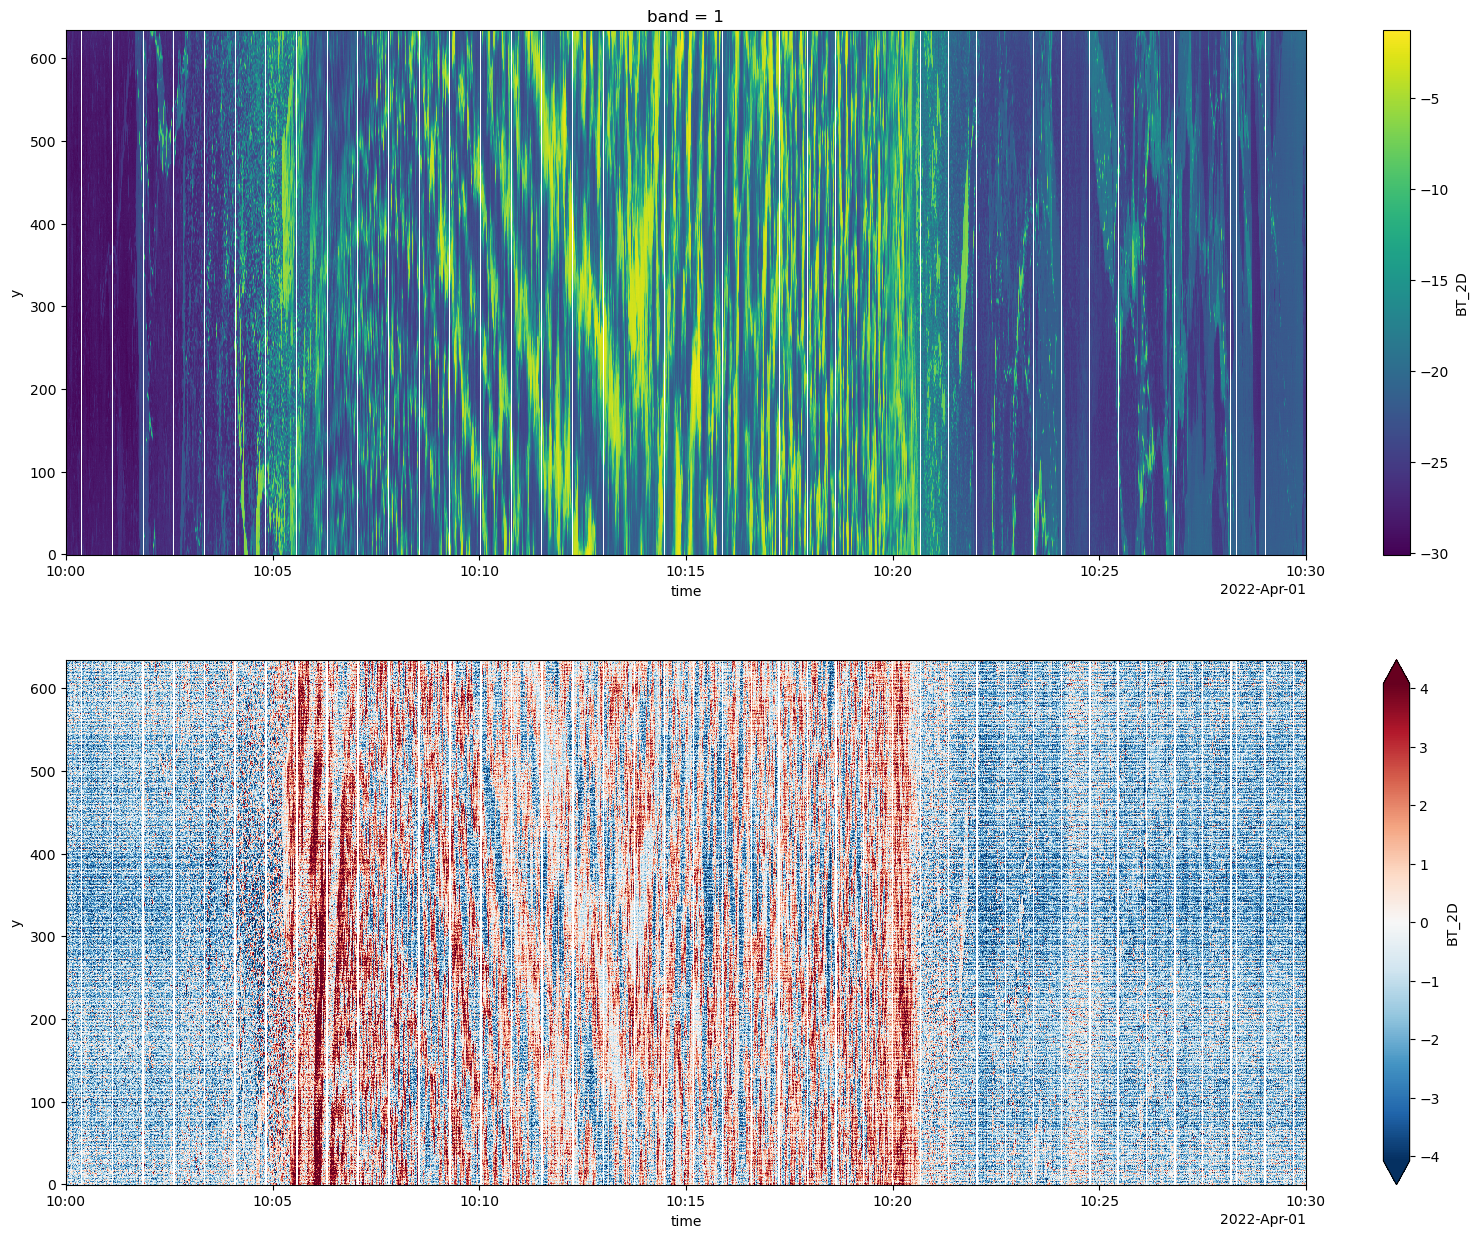

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, figsize=(20, 15))

ds_cc_corr.BT_2D.sel(band=1).plot(ax=ax[0])
(ds_cc_corr.BT_2D.sel(band=2) - ds_cc_corr.BT_2D.sel(band=6)).plot(ax=ax[1], robust=True)
# (ds_cc_corr.BT_2D.sel(band=3) - ds_cc_corr.BT_2D.sel(band=6)).plot(ax=ax[2])
# (ds_cc_corr.BT_2D.sel(band=5) - ds_cc_corr.BT_2D.sel(band=6)).plot(ax=ax[3])
# (ds_cc_corr.BT_2D.sel(band=5) - ds_cc_corr.BT_2D.sel(band=6)).plot(ax=ax[4])

In [ ]:
(ds_cc_corr.BT_2D.sel(band=2) - ds_cc_corr.BT_2D.sel(band=6)).sel(time=slice('2022-04-01T10:20:00', '2022-04-01T10:30:00')).plot(robust=True, figsize=(20, 10))

NameError: name 'ds_cc_corr' is not defined